In [1]:
import pandas as pd

# Load dataset directly from UCI (or download it and load locally)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"
columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv(url, names=columns)

# Explore the dataset
print(df.head())
print(df.info())
print(df['class'].value_counts())


  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB
None
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [5]:
from sklearn.preprocessing import LabelEncoder

# Label encode each column
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

# Features and target
X = df.drop('class', axis=1)
y = df['class']


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.92      0.94        83
           1       0.62      0.91      0.74        11
           2       1.00      1.00      1.00       235
           3       1.00      0.94      0.97        17

    accuracy                           0.97       346
   macro avg       0.90      0.94      0.91       346
weighted avg       0.98      0.97      0.98       346



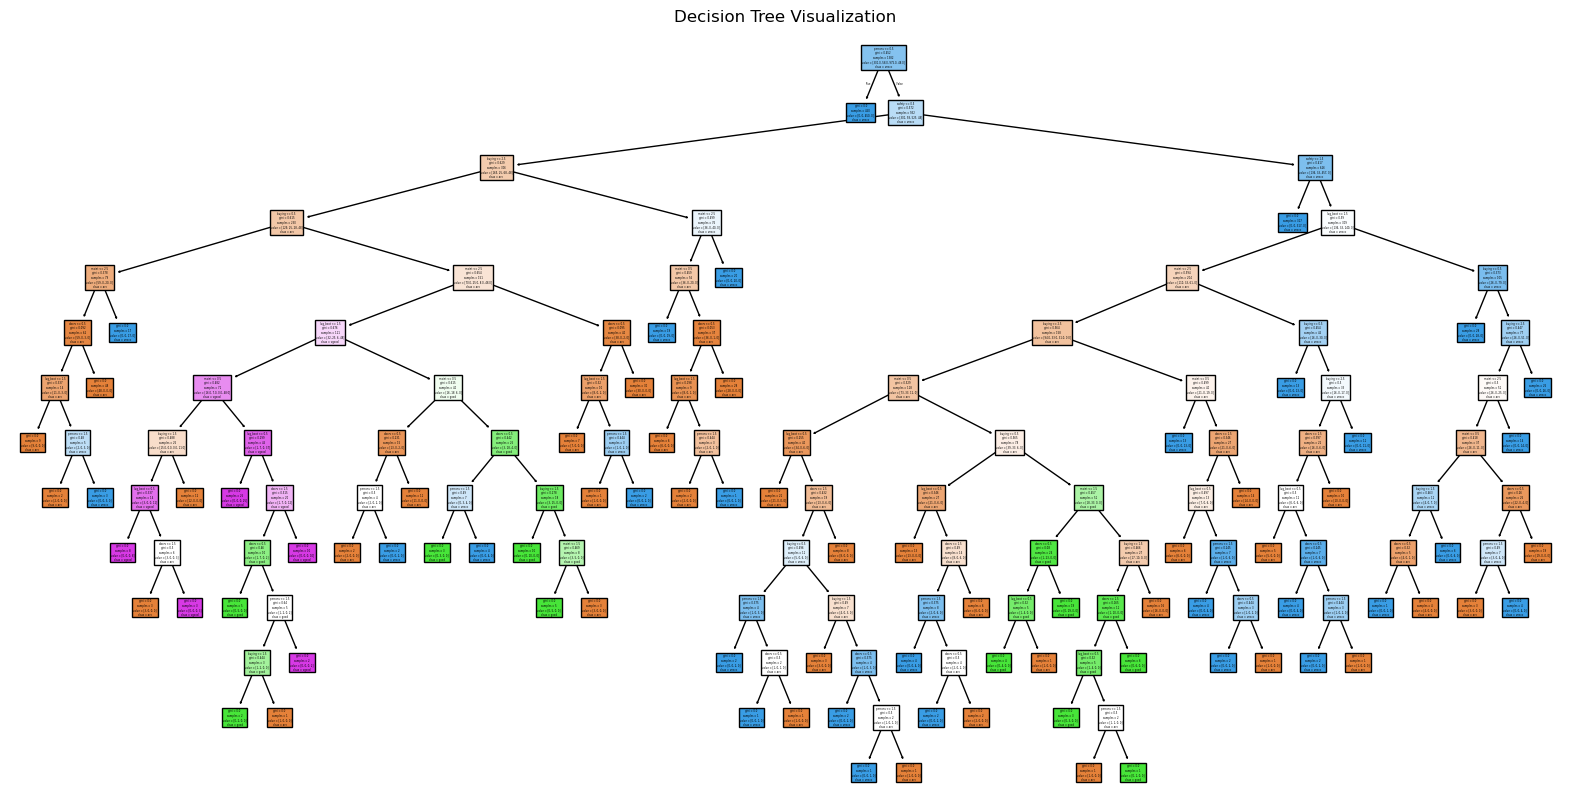

In [19]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Train a more flexible decision tree (no depth limit)
dt = DecisionTreeClassifier(
    max_depth=None,              # Allow full tree depth
    min_samples_split=2,         # Smallest possible split
    criterion='gini',            # You can also try 'entropy'
    random_state=42
)
dt.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt.predict(X_test)

# Show classification report with zero_division=0 to avoid warnings
print("Decision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_dt, zero_division=0))

# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=X.columns, class_names=le.classes_, filled=True)
plt.title("Decision Tree Visualization")
plt.show()


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_features='sqrt', bootstrap=True, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Report
print("Random Forest:\n", classification_report(y_test, y_pred_rf))


Random Forest:
               precision    recall  f1-score   support

           0       0.99      0.90      0.94        83
           1       0.65      1.00      0.79        11
           2       0.99      1.00      1.00       235
           3       1.00      0.94      0.97        17

    accuracy                           0.97       346
   macro avg       0.91      0.96      0.92       346
weighted avg       0.98      0.97      0.98       346



In [13]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(50, 30), activation='relu', solver='adam', learning_rate_init=0.01, max_iter=500)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

# Report
print("Neural Network:\n", classification_report(y_test, y_pred_mlp))


Neural Network:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        83
           1       0.75      0.82      0.78        11
           2       1.00      1.00      1.00       235
           3       0.93      0.82      0.88        17

    accuracy                           0.98       346
   macro avg       0.91      0.90      0.91       346
weighted avg       0.98      0.98      0.98       346



In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }

results = [
    get_metrics(y_test, y_pred_dt, "Decision Tree"),
    get_metrics(y_test, y_pred_rf, "Random Forest"),
    get_metrics(y_test, y_pred_mlp, "Neural Network")
]

results_df = pd.DataFrame(results)
print(results_df)


            Model  Accuracy  Precision    Recall  F1 Score
0   Decision Tree  0.973988   0.979049  0.973988  0.975417
1   Random Forest  0.973988   0.979891  0.973988  0.975242
2  Neural Network  0.979769   0.980118  0.979769  0.979725
